In [92]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [93]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.special import erf

from jax import config
config.update("jax_enable_x64", True)

In [94]:
t0, tfinal = 0.0, 0.5

In [95]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [96]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [97]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [98]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [99]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [100]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    x1_0 = u[:,:1]
    x2_0 = u[:,1:2]
    y1_0 = u[:,2:3]
    y2_0 = u[:,3:]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [101]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

params = deeponet.init(jax.random.PRNGKey(0), jnp.ones((10,)), jnp.ones((10,4)))

In [102]:
def defineCollocationPoints(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  xs = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))
  ys = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))

  zsensors = np.column_stack((xs, ys))

  return (ode_points, zsensors)

In [103]:
(de_points, zsensors) = defineCollocationPoints([t0, tfinal], 500)

In [104]:
@partial(jax.jit, static_argnums=(2,))
def w_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def w(t, z, component, params):
  return jax.vmap(w_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def w_t(t, z, component, params):
  return jax.vmap(jax.grad(w_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)
    
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [105]:
def train_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [106]:
epochs = 300
params, loss = train_network(params, de_points, zsensors, epochs)

Loss in epoch 0: 6.507501394354055
Loss in epoch 100: 0.028171863965135272
Loss in epoch 200: 0.02141532524621119


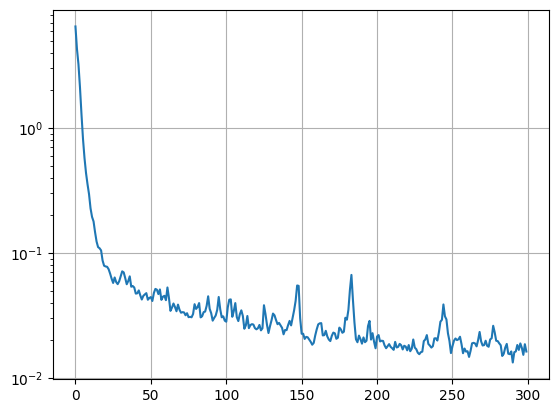

In [107]:
plt.semilogy(loss)
plt.grid()

In [108]:
n = 500
t = np.linspace(t0, tfinal, n)

x1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_data = (m2*l2**2*y1_data**2 + (m1+m2)*l1**2*y2_data**2 - 2*m2*l1*l2*y1_data*y2_data*np.cos(x1_data-x2_data))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_data-x2_data)**2))-(m1+m2)*grav*l1*np.cos(x1_data)-m2*grav*l2*np.cos(x2_data)

init_data = np.column_stack([x1_data, x2_data, y1_data, y2_data])
init_data_H = np.column_stack([x1_data, x2_data, y1_data, y2_data, H_data])

init_data = np.reshape(init_data, (-1,))
init_data_H = np.reshape(init_data_H, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)
z_init_H = np.repeat(np.expand_dims(init_data_H, axis=0), len(t), axis=0)

print(init_data.shape, z_init.shape)
print(init_data_H.shape, z_init_H.shape)

(4,) (500, 4)
(5,) (500, 5)


In [109]:
x1 = jax.vmap(w_model, [0, 0, None, None])(t, z_init, 0, params)
x2 = jax.vmap(w_model, [0, 0, None, None])(t, z_init, 1, params)
y1 = jax.vmap(w_model, [0, 0, None, None])(t, z_init, 2, params)
y2 = jax.vmap(w_model, [0, 0, None, None])(t, z_init, 3, params)

H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)
H = jnp.expand_dims(H, 1)

z = jnp.column_stack([x1, x2, y1, y2])

In [110]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

sol_rk = odeint(doublePendulum, init_data, t, rtol=1e-9)
x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]
Hrk = (m2*l2**2*y1rk**2 + (m1+m2)*l1**2*y2rk**2 - 2*m2*l1*l2*y1rk*y2rk*np.cos(x1rk-x2rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1rk-x2rk)**2))-(m1+m2)*grav*l1*np.cos(x1rk)-m2*grav*l2*np.cos(x2rk)

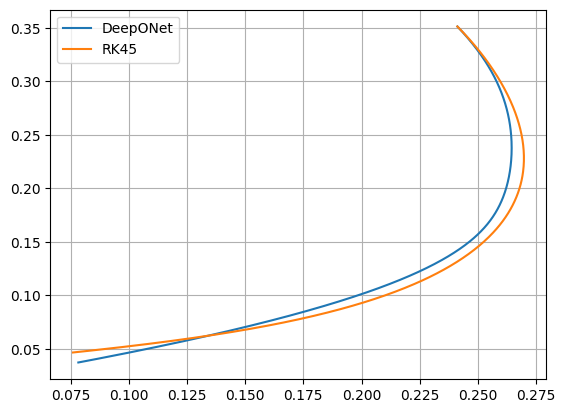

In [111]:
plt.plot(x1, x2)
plt.plot(x1rk, x2rk)

plt.grid()
plt.legend(['DeepONet','RK45'])

Text(0.5, 1.0, 'Solution time series')

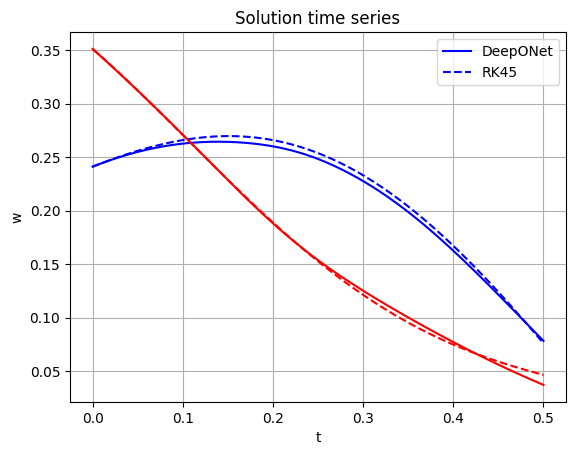

In [112]:
plt.plot(t, x1,'b')
plt.plot(t, x1rk,'b--')

plt.plot(t, x2, 'r')
plt.plot(t, x2rk, 'r--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')

Text(0.5, 1.0, 'Hamiltonian l2-error: 0.34587')

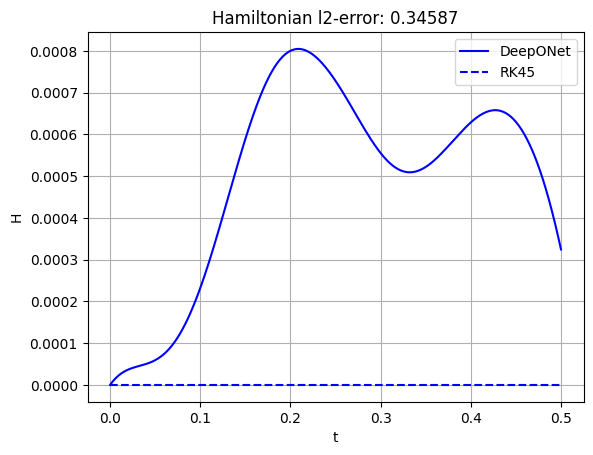

In [113]:
plt.plot(t, (H-H[0])/H[0],'b')
plt.plot(t, (Hrk-Hrk[0])/Hrk[0],'b--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('H')
plt.title(f'Hamiltonian l2-error: {np.linalg.norm((H-H[0])):2.5f}')

In [114]:
@jax.jit
def deriv_D(x, H_0) :

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    dH_dx1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    dH_dx2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    dH_dy1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    dH_dy2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    dD_dx1 = 2*(H_0 - H)*-dH_dx1
    dD_dx2 = 2*(H_0 - H)*-dH_dx2
    dD_dy1 = 2*(H_0 - H)*-dH_dy1
    dD_dy2 = 2*(H_0 - H)*-dH_dy2
    
    deriv_D = jnp.array([dD_dx1, dD_dx2, dD_dy1, dD_dy2])
    deriv_D = jnp.reshape(deriv_D, (-1, 1))

    return deriv_D

In [115]:
@jax.jit
def func_D(x, H_0) :
 
    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
   
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    D = (H_0 - H)**2
    
    return D

In [116]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    return 1/x

In [117]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter = args

    cond_1 = next_f - curr_f - c1*alpha*(curr_grad.T@p)
    cond_2 = next_grad.T@p - c2*(curr_grad.T@p)
    
    cond_1_bool = jax.lax.cond(cond_1[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    cond_2_bool = jax.lax.cond(cond_2[0][0] < 0.0 , lambda x: True, lambda x: False, None)
    cond_3_bool = jax.lax.cond(alpha >= 1e-2 , lambda x: True, lambda x: False, None)

    wolfe_bool = jnp.logical_or(cond_1_bool, cond_2_bool)
    final_bool = jnp.logical_and(wolfe_bool, cond_3_bool)
    # final_bool = wolfe_bool
    
    return final_bool

In [118]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = func_D(next_x, H_0)
    next_grad = deriv_D(next_x, H_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter)

In [119]:
@jax.jit
def BFGS(x, H_0) :

    x = jnp.reshape(x, (-1,1))
    x_0 = jnp.copy(x)
    
    iter = 0
    init_iter = 0
    alpha = 1.0
    c1 = 1e-4
    c2 = 0.9
    I_3 = jnp.identity(4, dtype = jnp.float64)
    B_0_inv = jnp.identity(4, dtype = jnp.float64)

    D_0 = func_D(x_0, H_0)
    gradD_0 = deriv_D(x_0, H_0)

    p = -1.0*alpha*(B_0_inv@gradD_0)

    # print(x_0, D_0, gradD_0)
    # input()

    next_x = x_0 + alpha*p
    next_D = func_D(next_x, H_0)
    next_gradD = deriv_D(next_x, H_0)

    # print(x_0, D_0, gradD_0, next_x, next_D, next_gradD, p)
    # input()

    init_args = (alpha, x_0, D_0, gradD_0, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 - step*(B_0_inv@gradD_0)

    while iter < 10:

        delta_x = x_1 - x_0

        D_1 = func_D(x_1, H_0)
        gradD_1 = deriv_D(x_1, H_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -1.0*alpha*(B_1_inv@gradD_1)
        
        next_x = x_1 + alpha*p
        next_D = func_D(next_x, H_0)
        next_gradD = deriv_D(next_x, H_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_next = x_1 - step*(B_1_inv@gradD_1)

        x_0 = x_1
        x_1 = x_next

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter = iter + 1


    return x_1

In [120]:
@jax.jit
def find_min_H(x, H_0) :

    return jax.vmap(BFGS, (0, 0), 0)(x, H_0)

In [121]:
z_vals = z
H_vals = z_init_H[:, 4:]

print(z_vals.shape, H_vals.shape)

(500, 4) (500, 1)


In [122]:
x_min = find_min_H(z_vals, H_vals)

x1_min = jnp.reshape(x_min[:,:1], (-1,))
x2_min = jnp.reshape(x_min[:,1:2], (-1,))
y1_min = jnp.reshape(x_min[:,2:3], (-1,))
y2_min = jnp.reshape(x_min[:,3:], (-1,))
H_min = (m2*l2**2*y1_min**2 + (m1+m2)*l1**2*y2_min**2 - 2*m2*l1*l2*y1_min*y2_min*np.cos(x1_min-x2_min))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_min-x2_min)**2))-(m1+m2)*grav*l1*np.cos(x1_min)-m2*grav*l2*np.cos(x2_min)



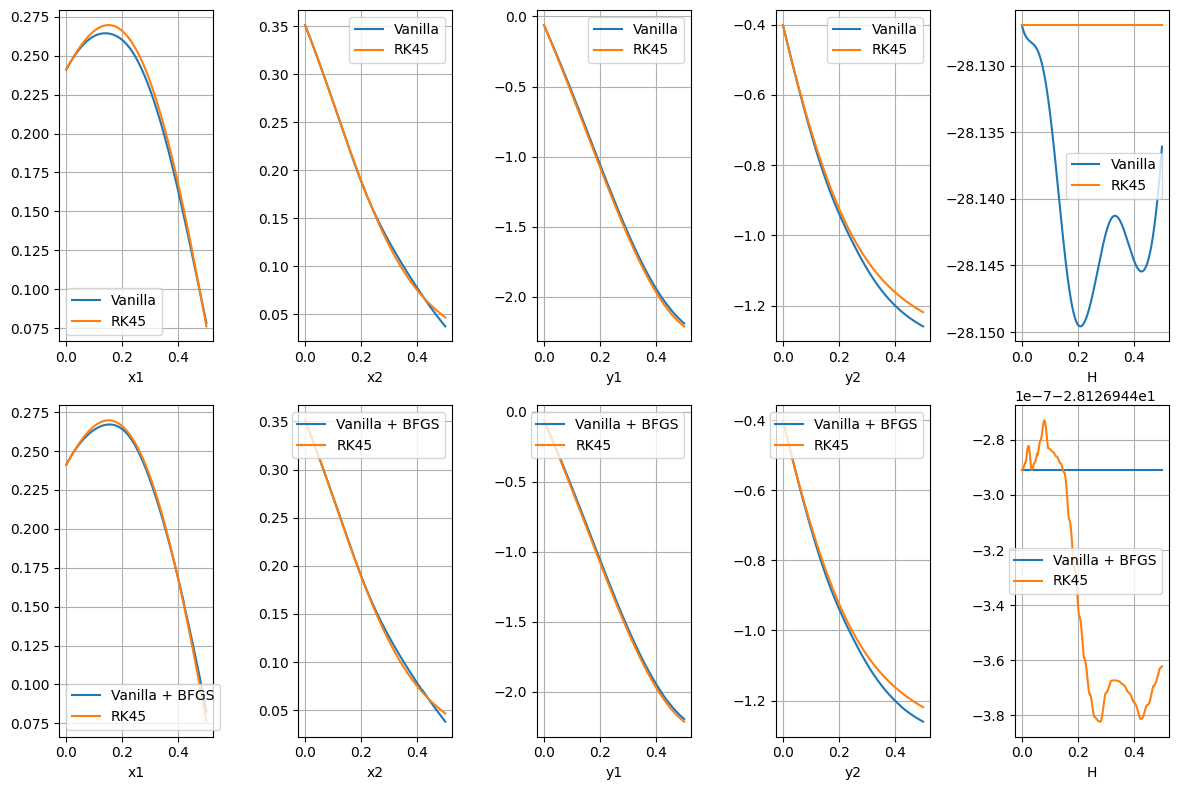

In [123]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, x1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, x2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, y1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, y2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, H)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, x1_min)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, x2_min)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, y1_min)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, y2_min)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, H_min)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])


plt.show()

In [124]:
class ClosestPoint(nn.Module):
    
    @nn.compact
    def __call__(self, inputs):

        x = inputs[0]
        H_0 = inputs[1]

        z_min = find_min_H(x, H_0)
    
        return z_min

In [125]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, z0):

    if z0.ndim == 1:
      z0 = jnp.reshape(z0, (1,-1))

    H_0 = z0[:, 4:]
    z0 = z0[:, :4]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(z0)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, z0[:,:1])([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, z0[:,1:2])([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, z0[:,2:3])([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, z0[:,3:])([t, y2])

    z = jnp.column_stack([x1, x2, y1, y2])

    z = ClosestPoint()([z, H_0])
      
    x1 = jnp.reshape(z[:,:1], (-1,))
    x2 = jnp.reshape(z[:,1:2], (-1,))
    y1 = jnp.reshape(z[:,2:3], (-1,))
    y2 = jnp.reshape(z[:,3:], (-1,))

    return x1, x2, y1, y2

In [126]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), jnp.ones((10,1)), jnp.ones((10,5)))

Cparams = copy.deepcopy(params)

In [127]:
@partial(jax.jit, static_argnums=(2,))
def cw_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def cw(t, z, component, params):
  return jax.vmap(cw_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def cw_t(t, z, component, params):
  return jax.vmap(jax.grad(cw_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def closs(params, t, z):

    x1 = cw(t, z, 0, params)
    x2 = cw(t, z, 1, params)
    y1 = cw(t, z, 2, params)
    y2 = cw(t, z, 3, params)
    
    x1_t = cw_t(t, z, 0, params)
    x2_t = cw_t(t, z, 1, params)
    y1_t = cw_t(t, z, 2, params)
    y2_t = cw_t(t, z, 3, params)
      
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

@jax.jit
def ctrain_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [131]:
def ctrain_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-6
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = coptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [132]:
x1_sens = zsensors[:, 0]
x2_sens = zsensors[:, 1]
y1_sens = zsensors[:, 2]
y2_sens = zsensors[:, 3]

H_sens = (m2*l2**2*y1_sens**2 + (m1+m2)*l1**2*y2_sens**2 - 2*m2*l1*l2*y1_sens*y2_sens*np.cos(x1_sens-x2_sens))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_sens-x2_sens)**2))-(m1+m2)*grav*l1*np.cos(x1_sens)-m2*grav*l2*np.cos(x2_sens)
czsensors = jnp.column_stack([x1_sens, x2_sens, y1_sens, y2_sens, H_sens])

print(czsensors.shape)

(500, 5)


In [133]:
epochs = 150
params, loss = ctrain_network(params, de_points, czsensors, epochs)

Loss in epoch 0: 4825.83964512995
Loss in epoch 1: 20.56933373152949
Loss in epoch 2: 20.021619543918938
Loss in epoch 3: 18.369929862903902
Loss in epoch 4: 17.960070009717917
Loss in epoch 5: 17.91407962350399
Loss in epoch 6: 17.880199939095277
Loss in epoch 7: 17.87286755116007
Loss in epoch 8: 17.867263153942602
Loss in epoch 9: 17.860169725786694
Loss in epoch 10: 17.857357342343587
Loss in epoch 11: 17.850771416914895
Loss in epoch 12: 17.842701217668054
Loss in epoch 13: 17.8374457072664
Loss in epoch 14: 17.834405575971186
Loss in epoch 15: 17.82433004956329
Loss in epoch 16: 17.81862652617212
Loss in epoch 17: 17.814324328322375
Loss in epoch 18: 17.80678317204063
Loss in epoch 19: 17.800276247816722
Loss in epoch 20: 17.791825713141517
Loss in epoch 21: 17.78646183942082
Loss in epoch 22: 17.781221284715095
Loss in epoch 23: 17.773553823575067
Loss in epoch 24: 17.768041982389647
Loss in epoch 25: 18.182987284763428
Loss in epoch 26: 18.17566968003271
Loss in epoch 27: 18.16

In [134]:
cx1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 0, params)
cx2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 1, params)
cy1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 2, params)
cy2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 3, params)

cH = (m2*l2**2*cy1**2 + (m1+m2)*l1**2*cy2**2 - 2*m2*l1*l2*cy1*cy2*np.cos(cx1-cx2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(cx1-cx2)**2))-(m1+m2)*grav*l1*np.cos(cx1)-m2*grav*l2*np.cos(cx2)

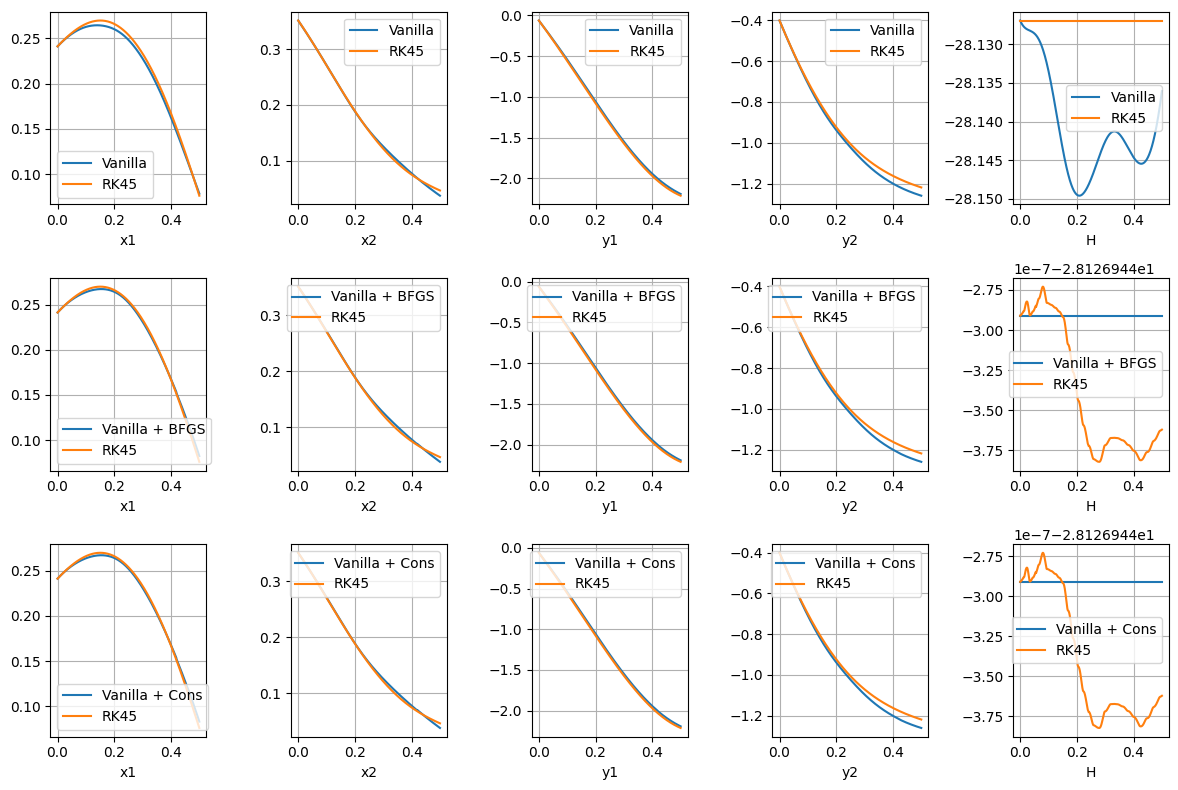

In [135]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, x1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, x2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, y1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, y2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, H)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, x1_min)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, x2_min)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, y1_min)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, y2_min)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, H_min)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, cx1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla + Cons','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, cx2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla + Cons','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, cy1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla + Cons','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, cy2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla + Cons','RK45'])

plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, cH)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla + Cons','RK45'])

plt.show()